In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Setup complete")

Setup complete


## Step 1: Causal Mask

GPT-2 is a **decoder-only** model. Unlike BERT, it generates text from left to right
and must **never look at future tokens** during training.

We enforce this with a **causal mask**: a lower-triangular matrix of 1s and 0s.
Position `i` can only attend to positions `0 ... i` (itself and everything before it).

```
For seq_len=4:
  [[1, 0, 0, 0],
   [1, 1, 0, 0],
   [1, 1, 1, 0],
   [1, 1, 1, 1]]
```

Positions with 0 are set to -infinity before softmax, so their attention weight becomes ~0.

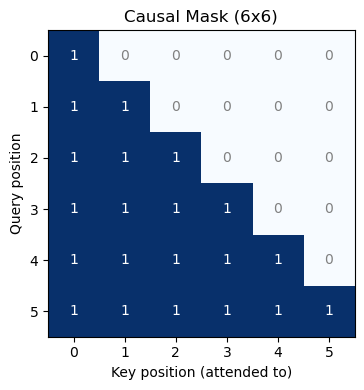

Causal mask shape: (6, 6)
Row 0 (first token): can only attend to position 0 = [1. 0. 0. 0. 0. 0.]
Row 3 (4th token):   can attend to positions 0-3  = [1. 1. 1. 1. 0. 0.]
Is lower triangular: True


In [2]:
def make_causal_mask(seq_len):
    """Lower-triangular mask: 1 = can attend, 0 = blocked."""
    return np.tril(np.ones((seq_len, seq_len), dtype=np.float32))

seq_len = 6
mask = make_causal_mask(seq_len)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(mask, cmap="Blues", vmin=0, vmax=1)
ax.set_title(f"Causal Mask ({seq_len}x{seq_len})")
ax.set_xlabel("Key position (attended to)")
ax.set_ylabel("Query position")
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, int(mask[i, j]), ha="center", va="center",
                color="white" if mask[i, j] == 1 else "gray", fontsize=10)
plt.tight_layout()
plt.savefig("../figures/09_causal_mask.png", dpi=100, bbox_inches="tight")
plt.show()

print("Causal mask shape:", mask.shape)
print("Row 0 (first token): can only attend to position 0 =", mask[0])
print("Row 3 (4th token):   can attend to positions 0-3  =", mask[3])
print("Is lower triangular:", np.allclose(mask, np.tril(mask)))

## Step 2: Causal Self-Attention

Scaled dot-product attention with the causal mask applied:

1. Compute scores: `scores = Q @ K.T / sqrt(d_k)`
2. **Apply mask**: set positions where `mask == 0` to `-1e9` (near -infinity)
3. Softmax over keys
4. Weighted sum of values

This is the core building block of every GPT-style model.

In [3]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)  # numerical stability
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def causal_attention(Q, K, V, mask):
    """
    Q, K, V: (seq_len, d_k)
    mask:    (seq_len, seq_len) -- 1=attend, 0=block
    Returns: (seq_len, d_k)
    """
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)          # (seq_len, seq_len)
    scores = scores + (1.0 - mask) * -1e9    # apply causal mask
    weights = softmax(scores, axis=-1)        # (seq_len, seq_len)
    return weights @ V, weights               # (seq_len, d_k)

# Small example: seq_len=4, d_k=8
np.random.seed(0)
SL, DK = 4, 8
Q = np.random.randn(SL, DK)
K = np.random.randn(SL, DK)
V = np.random.randn(SL, DK)
mask = make_causal_mask(SL)

out, attn_weights = causal_attention(Q, K, V, mask)

print("Output shape:", out.shape)
print()
print("Attention weight matrix (rows=query, cols=key):")
print(np.round(attn_weights, 3))
print()
print("Upper triangle should be ~0 (future tokens blocked):")
upper = attn_weights[np.triu_indices(SL, k=1)]
print("  Max upper-triangle weight:", upper.max().round(8))
print("  Rows sum to 1:", np.allclose(attn_weights.sum(axis=-1), 1.0))

Output shape: (4, 8)

Attention weight matrix (rows=query, cols=key):
[[1.    0.    0.    0.   ]
 [0.403 0.597 0.    0.   ]
 [0.314 0.264 0.422 0.   ]
 [0.82  0.086 0.023 0.072]]

Upper triangle should be ~0 (future tokens blocked):
  Max upper-triangle weight: 0.0
  Rows sum to 1: True


## Step 3: Byte Pair Encoding (BPE)

GPT-2 uses **Byte Pair Encoding** to tokenize text — no out-of-vocabulary words!

The idea is simple:
1. Start with characters as your vocabulary
2. Count all adjacent character pairs in the corpus
3. Merge the **most frequent** pair into a new token
4. Repeat until you reach your desired vocabulary size

Example: `"low lower newest"` → after merges, `"low"` becomes a single token.

GPT-2 uses 50,257 BPE tokens. We simulate the merging process on a tiny corpus.

In [4]:
# Pure-Python BPE merge demo (no external libraries)

def get_vocab(corpus):
    """Split corpus into word -> char-tuple frequency dict."""
    from collections import Counter
    vocab = Counter()
    for word in corpus.split():
        # Represent each word as a tuple of characters + end-of-word symbol
        chars = tuple(list(word) + ["</w>"])
        vocab[chars] += 1
    return vocab

def get_pair_counts(vocab):
    """Count frequency of every adjacent symbol pair."""
    from collections import Counter
    pairs = Counter()
    for symbols, freq in vocab.items():
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs

def merge_pair(pair, vocab):
    """Merge all occurrences of `pair` in vocab into a single token."""
    new_vocab = {}
    bigram = pair[0] + pair[1]  # merged token string
    for symbols, freq in vocab.items():
        new_syms = []
        i = 0
        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == pair[0] and symbols[i+1] == pair[1]:
                new_syms.append(bigram)
                i += 2
            else:
                new_syms.append(symbols[i])
                i += 1
        new_vocab[tuple(new_syms)] = freq
    return new_vocab

# Tiny corpus
corpus = "low low low lower lower newest newest highest"
vocab = get_vocab(corpus)

print("=== Initial vocabulary ===")
for word, freq in sorted(vocab.items(), key=lambda x: -x[1]):
    print(f"  {list(word)}  (x{freq})")

print()
NUM_MERGES = 8
merges = []
for step in range(NUM_MERGES):
    pairs = get_pair_counts(vocab)
    if not pairs:
        break
    best = max(pairs, key=pairs.get)
    merges.append(best)
    vocab = merge_pair(best, vocab)
    print(f"Merge {step+1}: {best[0]!r} + {best[1]!r} -> {best[0]+best[1]!r}  (freq={pairs[best]})")

print()
print("=== Vocabulary after BPE merges ===")
for word, freq in sorted(vocab.items(), key=lambda x: -x[1]):
    print(f"  {list(word)}  (x{freq})")

=== Initial vocabulary ===
  ['l', 'o', 'w', '</w>']  (x3)
  ['l', 'o', 'w', 'e', 'r', '</w>']  (x2)
  ['n', 'e', 'w', 'e', 's', 't', '</w>']  (x2)
  ['h', 'i', 'g', 'h', 'e', 's', 't', '</w>']  (x1)

Merge 1: 'l' + 'o' -> 'lo'  (freq=5)
Merge 2: 'lo' + 'w' -> 'low'  (freq=5)
Merge 3: 'low' + '</w>' -> 'low</w>'  (freq=3)
Merge 4: 'e' + 's' -> 'es'  (freq=3)
Merge 5: 'es' + 't' -> 'est'  (freq=3)
Merge 6: 'est' + '</w>' -> 'est</w>'  (freq=3)
Merge 7: 'low' + 'e' -> 'lowe'  (freq=2)
Merge 8: 'lowe' + 'r' -> 'lower'  (freq=2)

=== Vocabulary after BPE merges ===
  ['low</w>']  (x3)
  ['lower', '</w>']  (x2)
  ['n', 'e', 'w', 'est</w>']  (x2)
  ['h', 'i', 'g', 'h', 'est</w>']  (x1)


## Step 4: Mini GPT Block

A single GPT-2 transformer block applies these steps in order:

1. **Pre-LayerNorm** (applied BEFORE attention, unlike original Transformer which uses post-LN)
2. **Causal self-attention** (with residual connection)
3. **Pre-LayerNorm** again
4. **FFN with GELU activation** (with residual connection)

GPT-2's switch to Pre-LN makes training more stable. The model stacks 12-48 of these blocks.

GELU ("Gaussian Error Linear Unit") is smoother than ReLU and works better for language:
`GELU(x) ≈ 0.5 * x * (1 + tanh(sqrt(2/pi) * (x + 0.044715 * x^3)))`

In [5]:
def layer_norm(x, eps=1e-5):
    """Normalize across the last dimension."""
    mean = x.mean(axis=-1, keepdims=True)
    std  = x.std(axis=-1,  keepdims=True)
    return (x - mean) / (std + eps)

def gelu(x):
    """GELU approximation used in GPT-2."""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def gpt_block(x, W_qkv, W_proj, W_ff1, W_ff2):
    """
    One GPT-2 transformer block.

    x:      (seq_len, d_model)
    W_qkv:  (d_model, 3*d_model)  -- fused QKV projection
    W_proj: (d_model, d_model)    -- output projection
    W_ff1:  (d_model, 4*d_model)  -- FFN expand
    W_ff2:  (4*d_model, d_model)  -- FFN contract

    Returns: (seq_len, d_model)
    """
    seq_len, d_model = x.shape

    # --- Pre-LayerNorm + Causal Self-Attention ---
    x_norm = layer_norm(x)                           # pre-LN
    qkv = x_norm @ W_qkv                            # (seq_len, 3*d_model)
    Q, K, V = np.split(qkv, 3, axis=-1)             # each (seq_len, d_model)
    mask = make_causal_mask(seq_len)
    attn_out, _ = causal_attention(Q, K, V, mask)
    attn_out = attn_out @ W_proj                    # (seq_len, d_model)
    x = x + attn_out                                # residual

    # --- Pre-LayerNorm + FFN ---
    x_norm2 = layer_norm(x)                         # pre-LN
    ff_hidden = gelu(x_norm2 @ W_ff1)               # (seq_len, 4*d_model)
    ff_out = ff_hidden @ W_ff2                       # (seq_len, d_model)
    x = x + ff_out                                  # residual

    return x

# --- Demo forward pass ---
np.random.seed(7)
D = 16      # d_model (toy)
SEQ = 5     # sequence length
scale = 0.02

x_in   = np.random.randn(SEQ, D) * scale
W_qkv  = np.random.randn(D, 3 * D) * scale
W_proj = np.random.randn(D, D)     * scale
W_ff1  = np.random.randn(D, 4 * D) * scale
W_ff2  = np.random.randn(4 * D, D) * scale

x_out = gpt_block(x_in, W_qkv, W_proj, W_ff1, W_ff2)

print("GPT Block demo")
print("  Input  shape:", x_in.shape,  "(seq_len=%d, d_model=%d)" % (SEQ, D))
print("  Output shape:", x_out.shape, "(same -- residual stream preserved)")
print()
print("GELU vs ReLU comparison on [-3, 3]:")
xs = np.linspace(-3, 3, 7)
print("  x    :", xs.round(1))
print("  gelu :", gelu(xs).round(3))
print("  relu :", np.maximum(0, xs).round(3))
print()
print("Note: GELU is smooth near 0 (small negative values pass through slightly)")

GPT Block demo
  Input  shape: (5, 16) (seq_len=5, d_model=16)
  Output shape: (5, 16) (same -- residual stream preserved)

GELU vs ReLU comparison on [-3, 3]:
  x    : [-3. -2. -1.  0.  1.  2.  3.]
  gelu : [-0.004 -0.045 -0.159  0.     0.841  1.955  2.996]
  relu : [0. 0. 0. 0. 1. 2. 3.]

Note: GELU is smooth near 0 (small negative values pass through slightly)


## Step 5: Greedy Decoding & Temperature Sampling

After the GPT-2 block(s) produce hidden states, a linear head projects to **logits** over the vocabulary.
The model then picks the next token.

**Greedy decoding**: always pick `argmax(logits)`. Deterministic but can be repetitive.

**Temperature sampling**: divide logits by a temperature `T` before softmax.
- `T → 0`: more deterministic (sharp distribution)
- `T = 1`: use the raw model distribution
- `T > 1`: more random (flatter distribution)

Temperature controls the creativity vs. coherence trade-off.

Toy vocabulary: ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'ran', 'fast']
Logits: [0.1 3.5 0.8 0.2 1.  0.5 2.1 0.3]

Greedy decode -> token 1 = 'cat'

Temperature sampling (10 samples each):
  T=0.01 | top-token='cat'  | samples: ['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat']
  T=0.50 | top-token='cat'  | samples: ['cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat', 'cat']
  T=1.00 | top-token='cat'  | samples: ['mat', 'cat', 'ran', 'ran', 'mat', 'cat', 'cat', 'cat', 'cat', 'sat']
  T=2.00 | top-token='cat'  | samples: ['dog', 'fast', 'cat', 'cat', 'sat', 'cat', 'cat', 'sat', 'cat', 'mat']



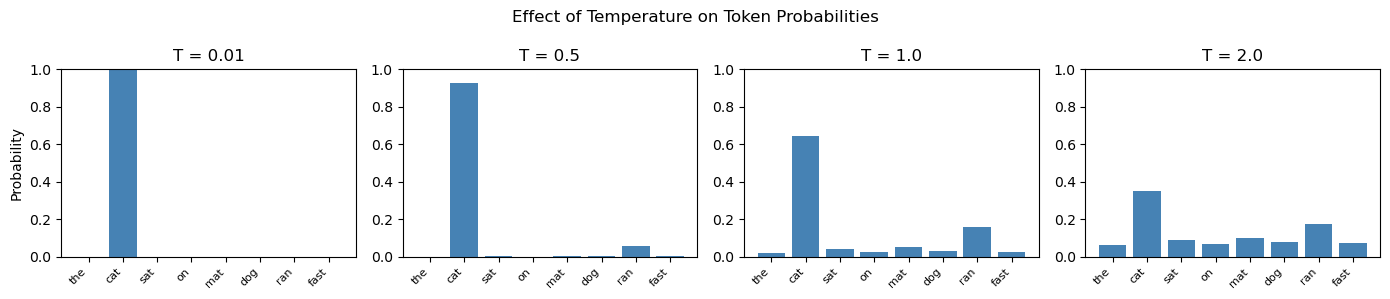

Saved temperature plot.


In [6]:
def greedy_decode(logits):
    """Return the token with the highest logit."""
    return int(np.argmax(logits))

def temperature_sample(logits, temperature=1.0, rng=None):
    """
    Sample from softmax(logits / temperature).
    temperature -> 0: greedy
    temperature -> inf: uniform random
    """
    if rng is None:
        rng = np.random.default_rng(42)
    scaled = logits / max(temperature, 1e-10)
    probs = softmax(scaled)
    return int(rng.choice(len(probs), p=probs))

# Toy vocabulary of 8 tokens
toy_vocab = ["the", "cat", "sat", "on", "mat", "dog", "ran", "fast"]
TVOCAB = len(toy_vocab)

# Simulate logits from the model (one position)
np.random.seed(3)
logits = np.array([0.1, 3.5, 0.8, 0.2, 1.0, 0.5, 2.1, 0.3])  # hand-crafted

print("Toy vocabulary:", toy_vocab)
print("Logits:", logits)
print()

greedy_tok = greedy_decode(logits)
print(f"Greedy decode -> token {greedy_tok} = '{toy_vocab[greedy_tok]}'")
print()

rng = np.random.default_rng(42)
temperatures = [0.01, 0.5, 1.0, 2.0]
print("Temperature sampling (10 samples each):")
for T in temperatures:
    probs = softmax(logits / T)
    samples = [toy_vocab[temperature_sample(logits, T, rng)] for _ in range(10)]
    top = toy_vocab[np.argmax(probs)]
    print(f"  T={T:.2f} | top-token={top!r:6s} | samples: {samples}")

print()
# Visualize probability distributions at different temperatures
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=False)
for ax, T in zip(axes, temperatures):
    probs = softmax(logits / T)
    ax.bar(range(TVOCAB), probs, color="steelblue")
    ax.set_xticks(range(TVOCAB))
    ax.set_xticklabels(toy_vocab, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"T = {T}")
    ax.set_ylabel("Probability" if T == 0.01 else "")
    ax.set_ylim(0, 1)
fig.suptitle("Effect of Temperature on Token Probabilities", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/09_temperature.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved temperature plot.")

## Step 6: Scaling Laws

In 2020, OpenAI published "Scaling Laws for Neural Language Models" (Kaplan et al.).
They found that validation loss follows a **power law** with compute:

`L(C) ≈ (C_min / C)^0.048`

On a **log-log plot**, this becomes a straight line:
`log(L) = const - 0.048 * log(C)`

This discovery was fundamental to the decision to scale up to GPT-3 (175B params) and beyond.
More compute = lower loss, predictably and reliably.

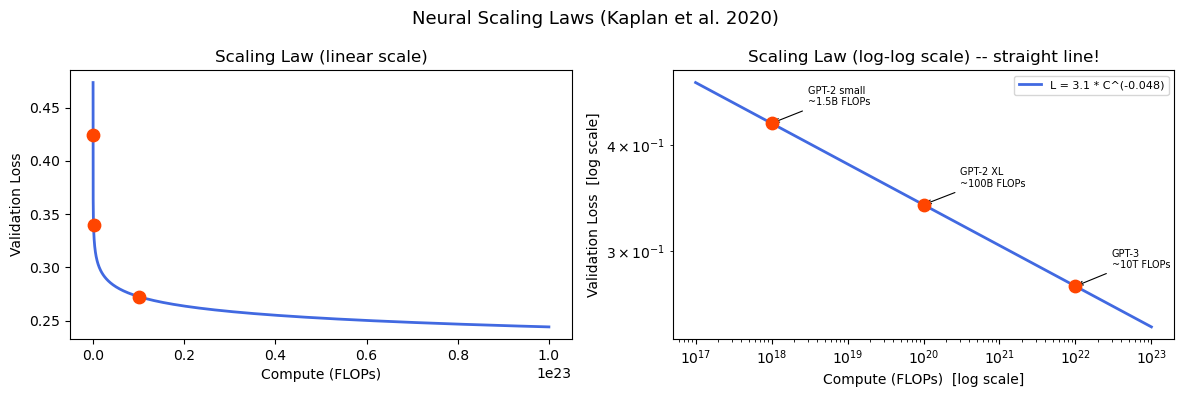

Scaling law: L(C) = 3.1 * C^(-0.048)

Predicted losses at reference compute:
  GPT-2 small  C=1e+18  ->  L=0.4240
  GPT-2 XL     C=1e+20  ->  L=0.3399
  GPT-3        C=1e+22  ->  L=0.2725

Key insight: on a log-log plot the power law is a straight line.
This means doubling compute ALWAYS reduces loss by the same fraction.
Slope = -0.048 (negative = more compute -> lower loss)


In [7]:
# Simulate the scaling law: L(C) = a * C^(-alpha)
alpha = 0.048   # exponent from Kaplan et al. 2020
a     = 3.1     # normalization constant (arbitrary for illustration)

# Compute budget range: 1e17 to 1e23 FLOPs (rough GPT-2 to GPT-3 range)
C = np.logspace(17, 23, 200)   # 200 points on log scale
L = a * (C ** (-alpha))        # power law loss

# Add a few annotated reference points
ref_compute = np.array([1e18, 1e20, 1e22])
ref_loss    = a * (ref_compute ** (-alpha))
ref_labels  = ["GPT-2 small\n~1.5B FLOPs", "GPT-2 XL\n~100B FLOPs", "GPT-3\n~10T FLOPs"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: linear scale
ax1.plot(C, L, color="royalblue", linewidth=2)
ax1.scatter(ref_compute, ref_loss, color="orangered", zorder=5, s=80)
ax1.set_xlabel("Compute (FLOPs)")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Scaling Law (linear scale)")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0,0))

# Right: log-log scale -- should look like a straight line
ax2.loglog(C, L, color="royalblue", linewidth=2, label=f"L = {a} * C^(-{alpha})")
ax2.scatter(ref_compute, ref_loss, color="orangered", zorder=5, s=80)
for xr, yr, lbl in zip(ref_compute, ref_loss, ref_labels):
    ax2.annotate(lbl, xy=(xr, yr), xytext=(xr*3, yr*1.05),
                 fontsize=7, arrowprops=dict(arrowstyle="->", lw=0.8))
ax2.set_xlabel("Compute (FLOPs)  [log scale]")
ax2.set_ylabel("Validation Loss  [log scale]")
ax2.set_title("Scaling Law (log-log scale) -- straight line!")
ax2.legend(fontsize=8)

plt.suptitle("Neural Scaling Laws (Kaplan et al. 2020)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/09_scaling_laws.png", dpi=100, bbox_inches="tight")
plt.show()

print("Scaling law: L(C) = %.1f * C^(-%.3f)" % (a, alpha))
print()
print("Predicted losses at reference compute:")
for xr, yr, lbl in zip(ref_compute, ref_loss, ref_labels):
    label_short = lbl.split("\n")[0]
    print(f"  {label_short:12s} C={xr:.0e}  ->  L={yr:.4f}")
print()
print("Key insight: on a log-log plot the power law is a straight line.")
print("This means doubling compute ALWAYS reduces loss by the same fraction.")
print("Slope =", -alpha, "(negative = more compute -> lower loss)")